In [2]:
from shapely.geometry import Point, LineString, Polygon
from shapely import geometry as geo
import pyclipper

<span style='color:red'>1.点相关的操作</span>

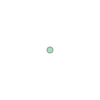

In [3]:
# 创建点对象
point = Point(1000,100)
point

In [147]:
# 计算点的坐标
x = point.x
y = point.y
print('---查看点的属性---')
print('x:',x, 'y:',y)

---查看点的属性---
x: 1000.0 y: 100.0


<span style='color:red'>2.线相关的操作</span>

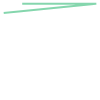

In [148]:
# 创建线对象
line = LineString([(0,0),(10,1),(2,1)])
line

In [6]:
# line = LineString([(0,0),(10,1),(2,1),(0,0)])
line = LineString([(0,0),(10,1),(2,1)])
# 判断线是否封闭
is_closed = line.is_closed
is_closed

False

<span style='color:red'>3.多边形相关的操作</span>

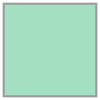

In [150]:
# 创建多边形对象
polygon = Polygon([(0,0),(0,1),(1,1),(1,0)])
polygon

In [151]:
import numpy as np
print(np.array(polygon))

POLYGON ((0 0, 0 1, 1 1, 1 0, 0 0))


576.0
16.0


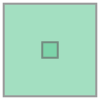

In [17]:
polygon_ = [(0,0),(0,4),(4,4),(4,0)]
# 创建多边形对象
polygon = Polygon(polygon_)
# subject = [tuple(l) for l in np.array(polygon)]
subject = polygon_
distance = 10
padding = pyclipper.PyclipperOffset()

# pyclipper.JT_ROUND：圆角连接（看起来更圆润）
# pyclipper.JT_MITER：保持原始角度（适合精确控制的场合）
# pyclipper.JT_SQUARE：直角连接
# pyclipper.JT_MITERCLIP：尖角连接
padding.AddPath(subject, pyclipper.JT_MITER,pyclipper.ET_CLOSEDPOLYGON)

# -distance<0: 向内收缩
# -distance>0: 向外扩张
padded_polygon = padding.Execute(distance)[0]
print(Polygon(padded_polygon).area)
print(polygon.area)
# 批量可视化
geo.GeometryCollection([Polygon(padded_polygon),polygon])

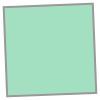

In [3]:
polygon_ = [(451,8.7),(372.43,5.7),(369.37,84.28),(447.93,87.34)]
# 创建多边形对象
polygon = Polygon(polygon_)
polygon

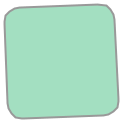

In [9]:
import numpy as np
distance = 16.51
padding = pyclipper.PyclipperOffset()
padding.AddPath(polygon_, pyclipper.JT_ROUND,
                pyclipper.ET_CLOSEDPOLYGON)

padded_polygon = np.array(padding.Execute(distance)[0]) 
Polygon(padded_polygon)

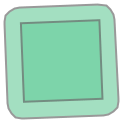

In [11]:
geo.GeometryCollection([Polygon(padded_polygon),polygon])

In [10]:
padded_polygon

array([[452,  -8],
       [457,  -7],
       [462,  -4],
       [466,   0],
       [467,   6],
       [467,   9],
       [463,  88],
       [462,  93],
       [459,  98],
       [455, 102],
       [446, 103],
       [368, 100],
       [363,  99],
       [358,  96],
       [354,  92],
       [353,  86],
       [353,  83],
       [356,   4],
       [357,  -1],
       [360,  -6],
       [364, -10],
       [370, -11],
       [373, -11]])

In [5]:
print(polygon)
polygon.area

POLYGON ((451 8.7, 372.43 5.7, 369.37 84.28, 447.93 87.34, 451 8.7))


6185.281599999999

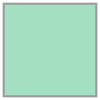

In [177]:
Polygon(padded_polygon)

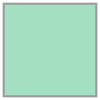

In [178]:
polygon

In [175]:
polygon.area

196.0

In [176]:
Polygon(padded_polygon).area

36.0

In [155]:
pyclipper.JT_ROUND

1

In [156]:
help(pyclipper)

Help on package pyclipper:

NAME
    pyclipper

PACKAGE CONTENTS
    _pyclipper
    _version

FUNCTIONS
    Area(...)
        Get area of the supplied polygon.
        More info: http://www.angusj.com/delphi/clipper/documentation/Docs/Units/ClipperLib/Functions/Area.htm
        
        Keyword arguments:
        poly -- closed polygon
        
        Returns:
        Positive number if orientation is True
        Negative number if orientation is False
    
    CleanPolygon(...)
        Removes unnecessary vertices from the provided polygon.
        More info: http://www.angusj.com/delphi/clipper/documentation/Docs/Units/ClipperLib/Functions/CleanPolygon.htm
        
        Keyword arguments:
        poly     -- polygon to be cleaned
        distance -- distance on which vertices are removed, see 'More info' (default: approx. sqrt of 2)
        
        Returns:
        cleaned polygon
    
    CleanPolygons(...)
        Removes unnecessary vertices from the provided polygons.
     

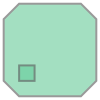

In [157]:

geo.GeometryCollection([Polygon(padded_polygon),polygon])

In [158]:
pyclipper.JT_ROUND

1

In [159]:
# 计算多边形的面积
area = polygon.area
print("计算多边形的面积:",area)
# 判断点是否在多边形内
is_inside = point.within(polygon)
print("判断点是否在多边形内：",is_inside)
# 判断2个几何对象是否相交
is_intersect = line.intersects(polygon)
print('线段是否于多边形相交:',is_intersect)

is_intersect = polygon.intersects(line)
print('多边形是否于线段相交:',is_intersect)

# 计算2个几何对象的交集
intersection = line.intersection(polygon)
print('线段与多边形的交集:',intersection)
# 计算2个几何对象的并集
union = line.union(polygon)
print('线段与多边形的并集:',union)

print('-'*18)

# 判断2个几何对象之间的距离
distance = point.distance(line)
print('点到线之间的距离:',distance)
distance = point.distance(polygon)
print('点到多边形之间的距离:',distance)

计算多边形的面积: 1.0
判断点是否在多边形内： False
线段是否于多边形相交: True
多边形是否于线段相交: True
线段与多边形的交集: LINESTRING (0 0, 1 0.1)
线段与多边形的并集: GEOMETRYCOLLECTION (POLYGON ((0 1, 1 1, 1 0.1, 1 0, 0 0, 0 1)), LINESTRING (1 0.1, 10 1, 2 1))
------------------
点到线之间的距离: 994.9376864909682
点到多边形之间的距离: 1003.8934206378683


2个矩形相交
2个矩形的交点: POLYGON ((4 2, 4 1, 2 1, 2 2, 4 2))


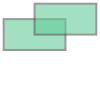

In [160]:
# 多边形之间的操作
rect1 = Polygon([(0,0),(4,0),(4,2),(0,2)]) # 矩形1的坐标
rect2 = Polygon([(2,1),(6,1),(6,3),(2,3)]) # 矩形2的坐标
# 判断2个矩形是否相交
if rect1.intersects(rect2):
    print("2个矩形相交")
else:
    print("2个矩形不相交")
# 计算2个矩形的交点
intersection = rect1.intersection(rect2) # POLYGON ((4 2, 4 1, 2 1, 2 2, 4 2))
# print('2个矩形的交点:',intersection)
if intersection.is_empty:
    print("2个矩形没有交点")
else:
    print('2个矩形的交点:',intersection)
# 批量可视化
geo.GeometryCollection([rect1,rect2])

In [161]:
print(intersection.boundary)

LINESTRING (4 2, 4 1, 2 1, 2 2, 4 2)


In [162]:
help(Polygon)

Help on class Polygon in module shapely.geometry.polygon:

class Polygon(shapely.geometry.base.BaseGeometry)
 |  Polygon(shell=None, holes=None)
 |  
 |  A two-dimensional figure bounded by a linear ring
 |  
 |  A polygon has a non-zero area. It may have one or more negative-space
 |  "holes" which are also bounded by linear rings. If any rings cross each
 |  other, the feature is invalid and operations on it may fail.
 |  
 |  Attributes
 |  ----------
 |  exterior : LinearRing
 |      The ring which bounds the positive space of the polygon.
 |  interiors : sequence
 |      A sequence of rings which bound all existing holes.
 |  
 |  Method resolution order:
 |      Polygon
 |      shapely.geometry.base.BaseGeometry
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Return self==value.
 |  
 |  __init__(self, shell=None, holes=None)
 |      Parameters
 |      ----------
 |      shell : sequence
 |          A sequence of (x, y [,z]) numeric coo